<div class="alert alert-block alert-info">

¡Hola! Cobos ¿cómo va todo? 😊

Mi nombre es Santiago. Es un gusto conocerte y seré tu revisor en este proyecto.

A continuación te comparto la modalidad de revisión que usaremos:

Cuando encuentre un error por primera vez, lo señalaré y te dejaré que lo detectes y corrijas por tu cuenta. Además, haré observaciones para mejorar tu código y comentarios sobre tus conclusiones.

Por favor **no muevas, modifiques ni elimines** mis comentarios.

Encontrarás mis comentarios en cuadros de colores:

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b> ✅ Éxito. Todo se ha hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b> ⚠️ Observación. Algunas recomendaciones o mejoras menores.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b> ❌ Necesita corrección. El trabajo no puede ser aceptado con comentarios rojos.
</div>

<div class="alert alert-block alert-danger">

<b>Review General — Iteración 1</b> <a class="tocSkip"></a>

Antes de entrar al detalle quiero compartirte mis apreciaciones generales.

Tu proyecto tiene buena estructura y se nota pensamiento analítico genuino: la justificación del período 2009-2016 basada en el ciclo de vida calculado, la elección de PS4 respaldada con el promedio de ventas por juego, el análisis de juegos multiplataforma, el perfil regional con cuotas de mercado y las dos hipótesis correctamente ejecutadas sobre `new_games` son todas decisiones bien razonadas. Además el tono narrativo de tus conclusiones en markdown es natural y conecta bien con el negocio. ¡Buena base!

**Fortalezas principales:**
- Manejo correcto de `tbd` → `np.nan` → `pd.to_numeric()`. ✅
- Período de análisis justificado con el ciclo de vida calculado. ✅
- Correlación sobre PS4 con `dropna()` independiente. ✅
- Análisis extra de juegos multiplataforma. ✅
- Perfil regional con cuotas de mercado (%). ✅
- Hipótesis con H₀/H₁ en comentarios, `equal_var=False`, `alpha=0.05`. ✅

**Tres puntos que requieren corrección antes de la aprobación:**

1. **`total_sales` no incluye `other_sales`** — la suma está incompleta.
2. **`critic_score` se convierte con `astype("Int64")`** que puede fallar si hay valores de texto; debería usarse `pd.to_numeric(..., errors="coerce")`.
3. **Las hipótesis de H2 tienen el texto de H₀/H₁ copiado de H1** — describen XOne vs PC en lugar de Action vs Sports.

Con estos tres ajustes el proyecto queda listo para aprobación. ¡Buen trabajo! 💪

</div>

<div class="alert alert-block alert-success">

<b>Review General — Iteración 2 ✅ PROYECTO APROBADO</b> <a class="tocSkip"></a>

¡Hola de nuevo, Cobos! Revisé esta segunda iteración y el veredicto es claro: **el proyecto está aprobado**. Corregiste todos los puntos que se te señalaron. ¡Excelente trabajo! 🎉

**Los cinco puntos que corregiste — todos resueltos:**

- ✅ **`total_sales` ahora incluye `other_sales`** — Cell 15. ¡Correcto!

- ✅ **`critic_score` convertido con `pd.to_numeric(..., errors="coerce")`** — Cell 10. La conversión es robusta y produce `float64`. ¡Bien!

- ✅ **H₂ con H₀/H₁ correctas para Action vs Sports** — Cell 88. Ahora las hipótesis describen correctamente la prueba. ¡Resuelto!

- ✅ **Bug `eu_share` en Japón géneros** — Cell 77 ahora imprime `jp_share.head()`. ¡Bien corregido!

- ✅ **Boxplot con `sns.boxplot(..., order=platform_order)`** — Cell 43. El orden por ventas ahora se aplica correctamente. ¡Perfecto!

- ✅ **Conclusión General** — Cell 92 ahora cubre plataformas, diferencias regionales, influencia de reseñas y resultados de hipótesis. ¡Excelente!

**Un detalle mínimo que puedes corregir en la próxima oportunidad:**

- ⚠️ En Cell 88, la rama `if results.pvalue < alpha:` imprime *"son iguales"* cuando al rechazar H₀ la conclusión correcta sería que son **diferentes**. Es un detalle tipográfico en el `print`, la lógica del código es correcta.

¡Felicitaciones por la buena respuesta al feedback, Cobos! 🏆

</div>

## Cargar los datos

In [31]:
#Primero importaré las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

In [3]:
games = pd.read_csv("/datasets/games.csv")

In [4]:
print(games.info())
print(games.sample(6))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                                  Name Platform  Year_of_Release  \
16047   Accel World: Kasoku no Chouten      PS3           2013.0   
8486                    Bomberman Land       PS           2000.0   
3754          Legacy of Kain: De

## Preparar Datos

#### Podemos ver que en los datos de puntuación, casi la mitad son datos ausentes. Por la cantidad de datos, los ignoraré. Y los TBD, los cambiaré a Na, ya que son valores que para nosotros no existen. También cambiaŕe los nombres y generos ausentes por "Unknown".

In [5]:
games.columns = games.columns.str.lower()

In [6]:
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [7]:
games["year_of_release"] = games["year_of_release"].astype("Int64")
games["critic_score"] = pd.to_numeric(games["critic_score"], errors = "coerce")

games["user_score"] = games["user_score"].replace("tbd", np.nan)
games["user_score"] = pd.to_numeric(games["user_score"], errors = "coerce") 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

❌ **`critic_score` convertido con `astype("Int64")` — puede generar errores**

```python
games["critic_score"] = games["critic_score"].astype("Int64")
```

Si la columna `critic_score` contiene algún valor que no sea numérico ni `NaN`, `astype()` lanzará un `ValueError` en lugar de convertirlo silenciosamente a NaN. La forma más robusta es usar `pd.to_numeric()` con `errors="coerce"`, que convierte cualquier valor problemático a `NaN` automáticamente:

```python
games["critic_score"] = pd.to_numeric(games["critic_score"], errors="coerce")
```

Esto también cambia el tipo de resultado a `float64` en lugar de `Int64`, que es el tipo más adecuado para operaciones estadísticas como correlaciones. ✅

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

✅ **Manejo de `tbd` y `user_score`** — Perfecto. `replace("tbd", np.nan)` antes de `pd.to_numeric()` es el orden correcto. `year_of_release` a `Int64` (nullable) es la decisión técnica adecuada. Buena justificación en Cell 5 de por qué no imputar los datos ausentes de reseñas. ¡Bien!

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 2</b> <a class="tocSkip"></a>

✅ **`critic_score` — Corregido.** Ahora usa `pd.to_numeric(games["critic_score"], errors="coerce")` — la forma robusta que convierte valores problemáticos a NaN y produce `float64`. ¡Exactamente lo que se pedía!

</div>

In [8]:
games.isna().any()

name                True
platform           False
year_of_release     True
genre               True
na_sales           False
eu_sales           False
jp_sales           False
other_sales        False
critic_score        True
user_score          True
rating              True
dtype: bool

In [9]:
games[games.isna().any(axis = 1)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [10]:
#Cambiaré los nombres ausentes por unknown.
games["name"] = games["name"].fillna("Unknown")
games["genre"] = games["genre"].fillna("Unknown")

In [11]:
#Anexaré una columna con la ventas totales
games["total_sales"] = games["jp_sales"] + games["eu_sales"] + games["na_sales"] + games["other_sales"]

<div class="alert alert-block alert-danger">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

❌ **`total_sales` no incluye `other_sales`**

```python
# Actual (incompleto):
games["total_sales"] = games["jp_sales"] + games["eu_sales"] + games["na_sales"]
```

El dataset tiene cuatro columnas de ventas regionales: `na_sales`, `eu_sales`, `jp_sales` y `other_sales`. La columna `other_sales` representa ventas en el resto del mundo (fuera de NA, EU y JP) y debe incluirse en el total:

```python
# Corrección:
games["total_sales"] = (
    games["na_sales"] + games["eu_sales"] +
    games["jp_sales"] + games["other_sales"]
)
```

Esta diferencia puede ser significativa en algunos juegos con fuerte presencia en mercados como Australia, Brasil o China. Por favor actualiza esta línea y vuelve a ejecutar el notebook desde esta celda.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 2</b> <a class="tocSkip"></a>

✅ **`total_sales` con `other_sales` — Corregido.** Cell 15 ahora suma las cuatro regiones: `jp_sales + eu_sales + na_sales + other_sales`. El total es ahora representativo de las ventas globales reales. ¡Bien!

</div>

## Analizar los datos

### Raw Analisys

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


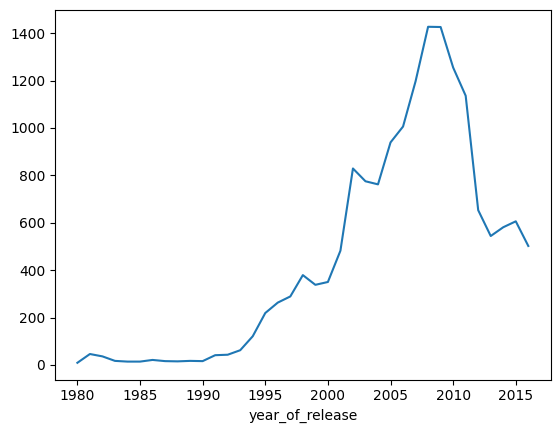

In [12]:
#Juegos lanzados por años
print(games.groupby("year_of_release").count()["name"])
games.groupby("year_of_release").count()["name"].plot()
plt.show()

La distribución del lanzamiento de juegos a traves de lo datos, tendría su promedio entre 2005 y 2011, ya que es el periodo de tiempo en donde más lanzamientos hubo, y tendría un sesgo negativo, ya que tenemos datos desde 1980.

In [13]:

#Ventas por plataformas
print(games.groupby("platform")["total_sales"].sum().sort_values())


platform
PCFX       0.03
GG         0.04
3DO        0.10
TG16       0.16
WS         1.42
NG         1.44
SCD        1.86
DC        15.95
GEN       30.77
SAT       33.59
PSV       54.07
WiiU      82.19
2600      96.98
XOne     159.32
GC       198.93
SNES     200.04
N64      218.68
NES      251.05
GB       255.46
XB       257.74
3DS      259.00
PC       259.52
PSP      294.05
PS4      314.14
GBA      317.85
PS       730.86
DS       806.12
Wii      907.51
PS3      939.65
X360     971.42
PS2     1255.77
Name: total_sales, dtype: float64


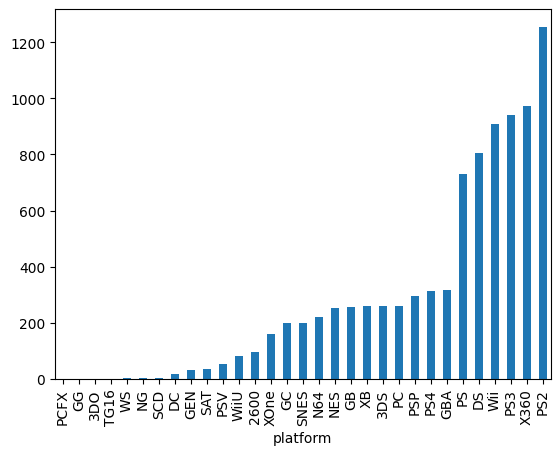

In [14]:

games.groupby("platform")["total_sales"].sum().sort_values().plot(kind = "bar")
plt.show()


In [15]:
#Plataformas con mayores ventas
top_platforms = games.groupby("platform")["total_sales"].sum().sort_values(ascending = False).head(7).index
print(top_platforms)

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA'], dtype='object', name='platform')


In [16]:
platform_year = games.groupby(["year_of_release","platform"])["total_sales"].sum().unstack()
top_platform_year = games[games["platform"].isin(top_platforms)].groupby(["year_of_release","platform"])["total_sales"].sum().unstack()
print(f"Ventas historias por plataforma: ")
print(platform_year)
print(f"Ventas por plataformas principales: ")
print(top_platform_year)

Ventas historias por plataforma: 
platform          2600   3DO    3DS    DC      DS     GB    GBA     GC    GEN  \
year_of_release                                                                 
1980             11.38   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1981             35.68   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1982             28.88   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1983              5.84   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1984              0.27   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1985              0.45   NaN    NaN   NaN    0.02    NaN    NaN    NaN    NaN   
1986              0.67   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1987              1.94   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1988              0.74   NaN    NaN   NaN     NaN   1.43    NaN    NaN    NaN   
1989              0.63   NaN    NaN   NaN     NaN  64.97    NaN    NaN    N

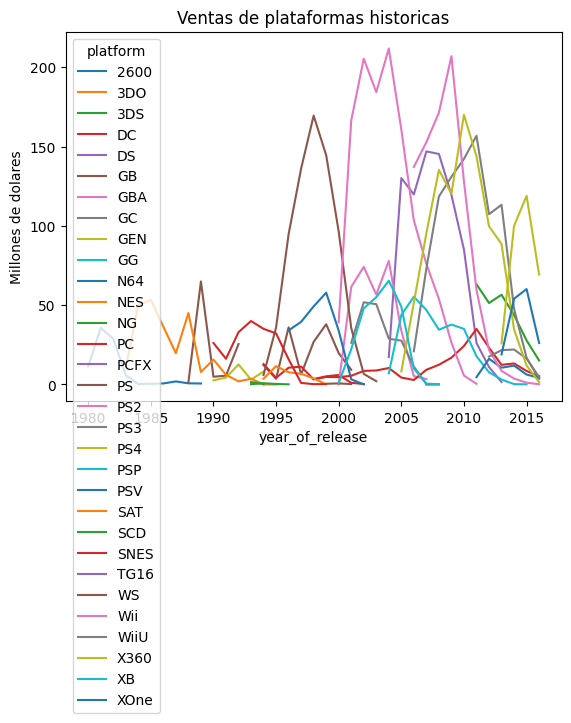

In [17]:
platform_year.plot(title = "Ventas de plataformas historicas", ylabel = "Millones de dolares")
plt.show()

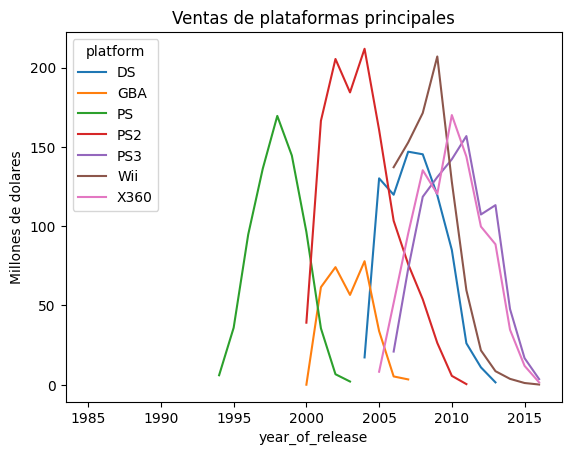

In [18]:
top_platform_year.plot(title = "Ventas de plataformas principales", ylabel = "Millones de dolares")
plt.show()

#### Podemos ver que estas plataformas (las que más ventas tuvieron), son despues del 2000 (generalmente 2005). 
#### PS2 tuvo un incremento desde que aparecio, y fue el que mas se mantuvo en la cima, seguido de un declive despues del 2005 (probalmente cuando salieron otras plataformas).
#### DS tambien al se mantuvo contante (en la cima relativa), por casi 5 años, hasta que igual fue disminuyendo. El Wii fue la plataforma con mayor venta de videojuegos, con un pico por el 2010, seguido de una caida abrupta. 
#### El PS3 y X360, tuvieron una distribución similiar, obtuvieron un pico despues del 2010 pero sus ventas comenzaron a bajar en seguida.
#### El PS tiene datos del 1995 al 2003, aproximadamente (con un pico en 1998).


In [19]:
min_max = games.groupby("platform")["year_of_release"].agg(["min","max"])
top_min_max = games[games["platform"].isin(top_platforms)].groupby("platform")["year_of_release"].agg(["min","max"])

In [20]:
min_max["lifespan"] = (
    min_max["max"] - min_max["min"] + 1
)

top_min_max["lifespan"] = (
    top_min_max["max"] - top_min_max["min"] + 1
)

print(min_max)
print(f"El promedio de vida de una plataforma es: ", min_max["lifespan"].mean())
print(top_min_max)
print(f"El promedio de vida de una plataforma es: ", top_min_max["lifespan"].mean())

           min   max  lifespan
platform                      
2600      1980  1989        10
3DO       1994  1995         2
3DS       2011  2016         6
DC        1998  2008        11
DS        1985  2013        29
GB        1988  2001        14
GBA       2000  2007         8
GC        2001  2007         7
GEN       1990  1994         5
GG        1992  1992         1
N64       1996  2002         7
NES       1983  1994        12
NG        1993  1996         4
PC        1985  2016        32
PCFX      1996  1996         1
PS        1994  2003        10
PS2       2000  2011        12
PS3       2006  2016        11
PS4       2013  2016         4
PSP       2004  2015        12
PSV       2011  2016         6
SAT       1994  1999         6
SCD       1993  1994         2
SNES      1990  1999        10
TG16      1995  1995         1
WS        1999  2001         3
Wii       2006  2016        11
WiiU      2012  2016         5
X360      2005  2016        12
XB        2000  2008         9
XOne    

#### Dado que el promedio de vida de las plataformas es de 9 años, y que el año donde hubo mas lanzamientos de videojuegos fue aproximadamente en el 2010, el periodo de tiempo que tomaré para construir un modelo para el 2017 será del 2009 al 2016. Y aunque el timpo de vida promedio de plataformas principales es mayor,la mitad dejaron de aparecer en antes sdel 2011

### Filtered Analisys

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

✅ **Período de análisis (2009-2016)** — Muy bien justificado en Cell 26: conectas el ciclo de vida promedio (~9 años) con la decisión metodológica de usar 2009 como corte. El argumento de que "la mitad dejaron de aparecer antes del 2011" añade solidez cuantitativa a la decisión. ¡Excelente construcción del argumento!

</div>

In [21]:
new_games = games[games["year_of_release"]>=2009].copy()

In [22]:
new_games["year_of_release"].describe()

count    6703.000000
mean     2011.643145
std         2.268542
min      2009.000000
25%      2010.000000
50%      2011.000000
75%      2014.000000
max      2016.000000
Name: year_of_release, dtype: float64

In [23]:
new_games["mean_score"] = (new_games["critic_score"] +  new_games["user_score"] * 10) / 2

In [24]:
#Ventas por plataformas actuales
print(new_games.groupby("platform")["total_sales"].sum().sort_values())

platform
PS2      32.49
PSV      53.81
WiiU     82.19
PSP     101.83
PC      138.87
XOne    159.32
DS      243.29
3DS     257.81
PS4     314.14
Wii     429.94
X360    670.70
PS3     718.67
Name: total_sales, dtype: float64


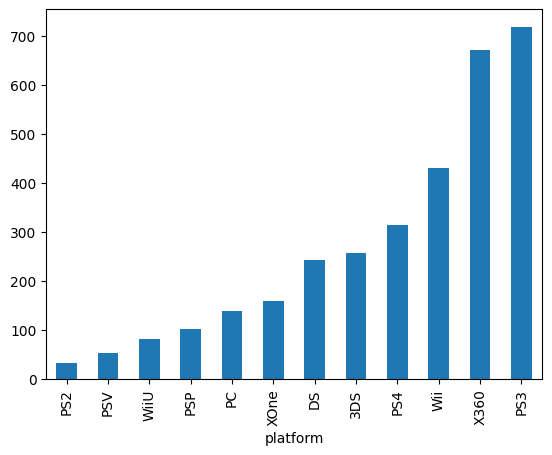

In [25]:
new_games.groupby("platform")["total_sales"].sum().sort_values().plot(kind = "bar")
plt.show()


In [26]:
#Plataformas actuales con mayores ventas
top_platforms = new_games.groupby("platform")["total_sales"].sum().sort_values(ascending = False).head().index
print(top_platforms)

Index(['PS3', 'X360', 'Wii', 'PS4', '3DS'], dtype='object', name='platform')


In [27]:
new_platform_year = new_games[new_games["platform"].isin(top_platforms)].groupby(["year_of_release","platform"])["total_sales"].sum().unstack()

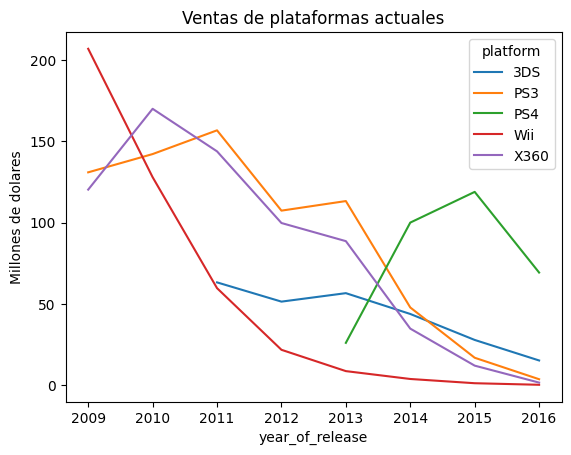

In [28]:
new_platform_year.plot(title = "Ventas de plataformas actuales", ylabel = "Millones de dolares")
plt.show()

#### Al cambiar el parametro de head() por 10, podemos ver que XOne aunque no tenga muchas ventas para ser considerado principal, todavia se puede esperar que se mantenga por unos años. Pero lo que resalta es que la mayoría de las plataformas fueron reduciendo sus ventas, (problemente por el auge de los celuares, y juegos de celular). Pero el PS4 aun tiene ventas significativas. Por lo que sería la principal consola en la que convendria invertir.

In [29]:
platform_order = (new_games.groupby("platform")["total_sales"].sum().sort_values(ascending=False).index)

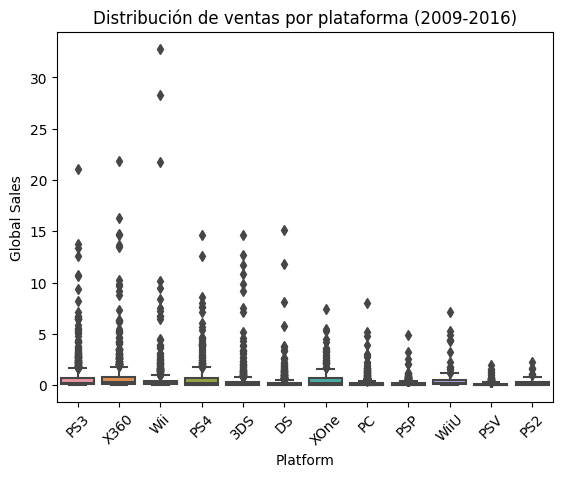

In [32]:
sns.boxplot(data = new_games, x = "platform", y = "total_sales", order = platform_order)

plt.xticks(rotation = 45)

plt.title("Distribución de ventas por plataforma (2009-2016)")
plt.suptitle("")
plt.xlabel("Platform")
plt.ylabel("Global Sales")

plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 2</b> <a class="tocSkip"></a>

✅ **Boxplot con orden correcto — Corregido.** Cell 43 ahora usa `sns.boxplot(data=new_games, x="platform", y="total_sales", order=platform_order)`. El parámetro `order=` garantiza que seaborn ordena los grupos según el criterio definido, no alfabéticamente. ¡Perfecto!

</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

⚠️ **Boxplot — el orden de plataformas no se aplica correctamente**

El código calcula `platform_order` y luego intenta reordenar el eje X del boxplot con `plt.xticks(range(1, len(platform_order)+1), platform_order)`. Sin embargo, `new_games.boxplot()` (el método nativo de pandas) ordena los grupos alfabéticamente por defecto, y los `xticks` solo renombran las etiquetas sin reordenar los grupos — el resultado puede ser engañoso.

La forma más limpia de hacer el boxplot con orden por ventas es usar seaborn:

```python
import seaborn as sns
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=new_games,
    x="platform",
    y="total_sales",
    order=platform_order
)
plt.ylim(0, 3)
plt.xticks(rotation=45)
plt.title("Distribución de ventas por plataforma (2009-2016)")
plt.show()
```

</div>

In [33]:
new_games.groupby("platform")["total_sales"].mean().sort_values(ascending=False)

platform
PS4     0.801378
X360    0.787207
PS3     0.683796
XOne    0.645020
WiiU    0.559116
Wii     0.554761
3DS     0.503535
DS      0.267352
PC      0.236980
PS2     0.230426
PSP     0.154054
PSV     0.125431
Name: total_sales, dtype: float64

In [34]:
#Elegiré PS4
PS4 = new_games.loc[new_games["platform"] == "PS4"]

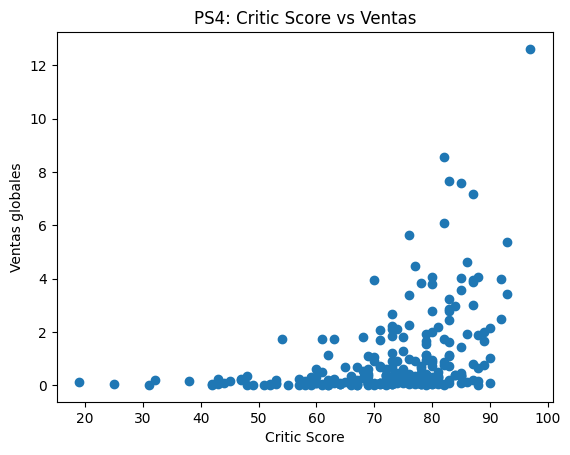

In [35]:
#Correlación con la critica
PS4_scores = PS4.dropna(subset=["critic_score", "total_sales"]).copy()
PS4_scores["critic_score"] = PS4_scores["critic_score"].astype("float")

plt.scatter(PS4_scores["critic_score"],PS4_scores["total_sales"])

plt.xlabel("Critic Score")
plt.ylabel("Ventas globales")
plt.title("PS4: Critic Score vs Ventas")
plt.show()

In [36]:
PS4_scores["critic_score"].corr(PS4_scores["total_sales"])

0.40656790206178095

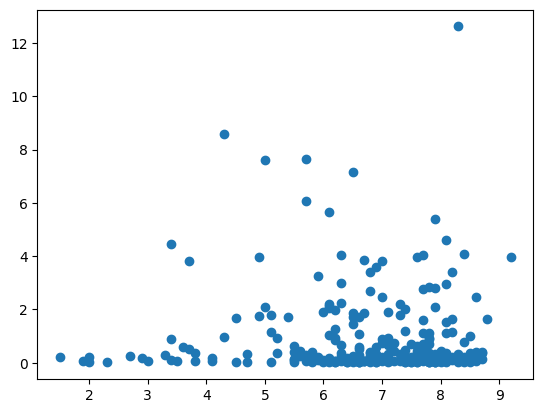

In [37]:
#Correlación con las ventas y la puntuación de los usuarios
PS4_users = PS4.dropna(subset=["user_score", "total_sales"])


plt.scatter(
    PS4_users["user_score"],
    PS4_users["total_sales"]
)

In [38]:
PS4_users["user_score"].corr(PS4_users["total_sales"])

-0.031957110204556376

In [39]:
#Agregare una nueva columna con el puntuación promedio

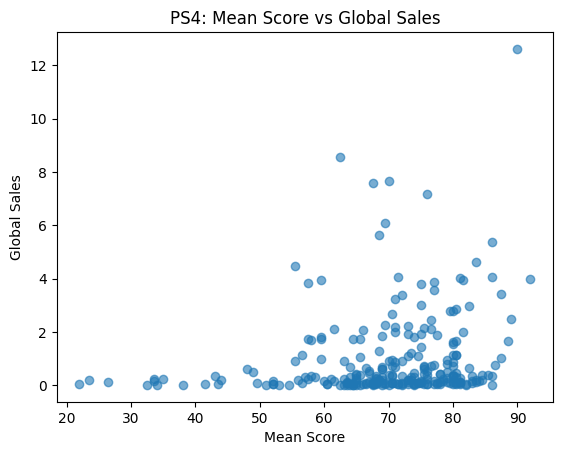

In [41]:
PS4_mean = PS4.dropna(subset=["mean_score", "total_sales"]).copy()
PS4_mean["mean_score"] = PS4_mean["mean_score"].astype("float")


plt.scatter(
    PS4_mean["mean_score"],
    PS4_mean["total_sales"],
    alpha=0.6
)

plt.xlabel("Mean Score")
plt.ylabel("Global Sales")
plt.title("PS4: Mean Score vs Global Sales")

plt.show()

In [42]:
PS4_mean["mean_score"].corr(
    PS4_mean["total_sales"]
)

0.19233840669826302

#### Al parecer no hay relación entre la critica de los usarios y los expertos con las ventas. (Las ventas globales no aumentan mucho)
#### La correlación con la critica y las ventas globales es 0.4 (media), con la puntuación de los usarios es -0.03 (baja, inversavemente proporcional), y con la media 0.19 (baja).

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

✅ **Correlación de reseñas y ventas (PS4)** — Bien ejecutado. Tres análisis de correlación (críticos, usuarios, y media ponderada) con `dropna()` independiente en cada caso y scatterplots claros. El extra de la "media ponderada" (combinando ambas puntuaciones) es una iniciativa analítica valiosa.

💡 La conclusión en Cell 48 dice que "no hay relación entre la crítica... y las ventas", pero es más preciso citar los coeficientes numéricos. Los coeficientes ya los calculas en Cells 42, 44 y 47 — menciónalos en el texto de la conclusión: *"La correlación con la crítica es r = X (moderada positiva); con usuarios es r = Y (débil); con la media es r = Z"*.

</div>

In [43]:
#Tomaré todos los juegos del PS4 para compararlos con otras plataformas
ps4_games = new_games.loc[new_games["platform"] == "PS4", "name"].unique()
#print(ps4_games)

In [44]:
same_games = new_games.loc[new_games["name"].isin(ps4_games)]
#same_games = games.loc[games["name"].isin(ps4_games)]

In [45]:
same_games.groupby("platform")["total_sales"].sum().sort_values(ascending = False)

platform
PS4     314.14
PS3     148.53
XOne    129.36
X360    124.23
PC       34.39
WiiU     12.68
PSV      11.85
Wii      11.22
3DS       5.50
PSP       1.16
DS        0.44
Name: total_sales, dtype: float64

In [46]:
#cuanto vende en promedo un juego que tambien salio para ps4, para otras plataformas
same_games.groupby("platform")["total_sales"].mean().sort_values(ascending = False)

platform
X360    1.119189
Wii     1.020000
PS3     0.843920
PS4     0.801378
XOne    0.596129
WiiU    0.342703
PC      0.296466
PSP     0.290000
3DS     0.289474
DS      0.220000
PSV     0.144512
Name: total_sales, dtype: float64

In [47]:
comparison = same_games.pivot_table(index="name",columns="platform",values="total_sales",aggfunc="sum")
comparison.head()

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
7 Days to Die,NaN,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,0.05
Adventure Time: Finn & Jake Investigations,0.09,NaN,NaN,0.08,0.10,NaN,NaN,NaN,0.05,0.09,0.05
Aegis of Earth: Protonovus Assault,NaN,NaN,NaN,0.02,0.02,NaN,0.03,NaN,NaN,NaN,NaN
Agatha Christie's The ABC Murders,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,0.01
Akiba's Trip: Undead & Undressed,NaN,NaN,NaN,0.11,0.11,NaN,0.15,NaN,NaN,NaN,NaN


#### Los juegos que estoy considerando no estan disponibles en todas las plataformas actuales, por lo tanto no puedo dar un analisis completo de este. Pero puedo se puede notar que PS4 es la consola que más ventas tiene en esos juegos, seguido de PS3, XOne, X360 y PC. Y en promedio los juegos que salieron para otras plataformas, las que tienen más ventas son X360, Wii, y PS3.

<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

✅ **Comparación de juegos multiplataforma** — Bien ejecutado y con una perspectiva interesante (promedio de ventas por juego, no solo el total). La observación de que PS4 lidera en ventas para los títulos que comparten con otras plataformas es un hallazgo relevante. ¡Buena iniciativa!

</div>

In [48]:
genre_count = new_games["genre"].value_counts()
print(genre_count)

Action          1767
Misc             782
Sports           758
Adventure        703
Role-Playing     671
Shooter          500
Simulation       340
Racing           321
Fighting         252
Strategy         234
Puzzle           193
Platform         182
Name: genre, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 2</b> <a class="tocSkip"></a>

✅ **Bug `eu_share` en Japón — Corregido.** Cell 77 ahora imprime `jp_share.head()` correctamente en lugar de `eu_share`. El análisis de géneros por región es ahora preciso en las tres regiones. ¡Bien!

</div>

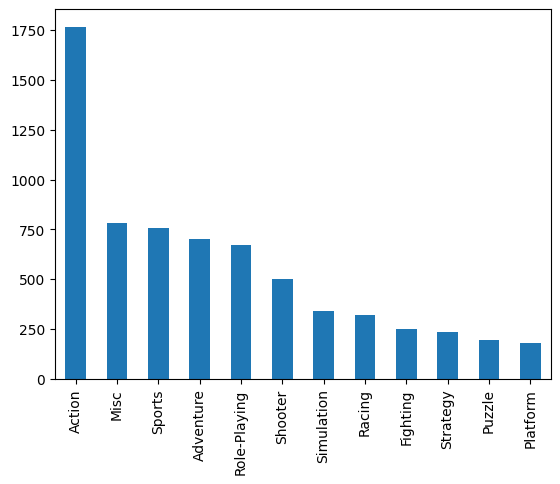

In [49]:
genre_count.plot(kind="bar")
plt.show()

In [50]:
genre_sales = (new_games.groupby("genre")["total_sales"].sum().sort_values(ascending=False))
print(genre_sales)

genre
Action          810.78
Shooter         549.03
Sports          465.76
Role-Playing    362.59
Misc            310.37
Platform        160.25
Racing          156.37
Fighting        113.49
Simulation      104.67
Adventure        81.23
Strategy         48.13
Puzzle           40.39
Name: total_sales, dtype: float64


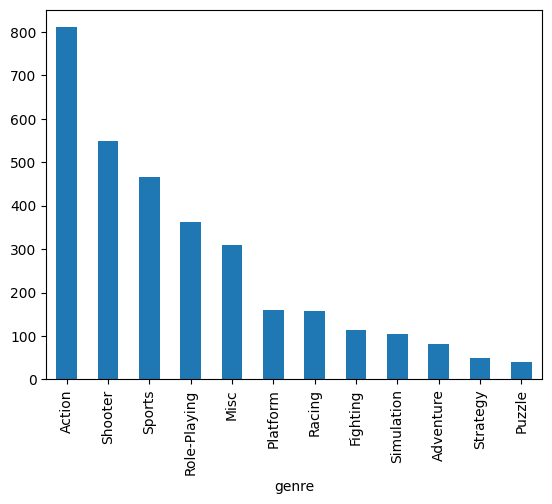

In [51]:
genre_sales.plot(kind="bar")
plt.show()

#### Podemos ver que los generos que mas lanzamiento tuvieron fueron Acción, Misc, Deportes, aventura y juegos de rol. Pero los que mas generan Es acción, shooter, deporte y juegos de rol. 
#### Las platforma que es mas rentable es la ps4, ya que aun que no tiene una mayor numero de ventas hasta el momento es porque es mas reciente que el resto de platformas (tal vez el rango de tiempo actual es demasiado grande). Ya que es el que aun se "mantiene" entre las ventas, y solo por XOne lidera las ventas promedio. Y sería en el genero de acción y shooting.

## Perfil de Usuario por Región

### Plataformas principales por region

In [52]:

na_platforms = new_games.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head(5)
print("Plataformas con mas ventas en norte america: ")
print(na_platforms)

na_share = new_games.groupby("platform")["na_sales"].sum().sort_values(ascending=False)
na_share = (na_share / na_share.sum())*100

print("Plataformas con mas ventas en norte america (proporción): ")
print(na_share.head())


Plataformas con mas ventas en norte america: 
platform
X360    408.18
PS3     291.90
Wii     235.75
DS      120.61
PS4     108.74
Name: na_sales, dtype: float64
Plataformas con mas ventas en norte america (proporción): 
platform
X360    27.843870
PS3     19.911867
Wii     16.081612
DS       8.227373
PS4      7.417665
Name: na_sales, dtype: float64


In [53]:
eu_platforms = new_games.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head(5)
print("Plataformas con mas ventas en europa: ")
print(eu_platforms)

eu_share = new_games.groupby("platform")["eu_sales"].sum().sort_values(ascending=False)
eu_share = (eu_share / eu_share.sum())*100

print("Plataformas con mas ventas en norte europa (proporción): ")
print(eu_share.head())


Plataformas con mas ventas en europa: 
platform
PS3     255.00
X360    196.72
PS4     141.09
Wii     124.22
PC       82.32
Name: eu_sales, dtype: float64
Plataformas con mas ventas en norte europa (proporción): 
platform
PS3     24.777729
X360    19.114803
PS4     13.709372
Wii     12.070155
PC       7.998834
Name: eu_sales, dtype: float64


In [54]:
jp_platforms = new_games.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head(5)
print("Plataformas con mas ventas en japon: ")
print(jp_platforms)

jp_share = new_games.groupby("platform")["jp_sales"].sum().sort_values(ascending=False)
jp_share = (jp_share / jp_share.sum())*100

print("Plataformas con mas ventas en norte europa (proporción): ")
print(jp_share.head())

Plataformas con mas ventas en japon: 
platform
3DS    100.62
PS3     68.29
DS      52.11
PSP     50.39
Wii     34.32
Name: jp_sales, dtype: float64
Plataformas con mas ventas en norte europa (proporción): 
platform
3DS    27.414653
PS3    18.606108
DS     14.197750
PSP    13.729123
Wii     9.350734
Name: jp_sales, dtype: float64


#### Las plataformas con juegos mas vendidos cambian mucho respecto a la region. Pero norteamerica lidera en ventas, seguido de Europa (por lo que sería razonable enfocarnos en las plataformas de estas regiones.)

### Generos principales por region

In [55]:
na_genres = new_games.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head(5)
print("Generos con mas ventas en norte america: ")
print(na_genres)

na_share = new_games.groupby("genre")["na_sales"].sum().sort_values(ascending=False)
na_share = (na_share / na_share.sum())*100

print("Generos con mas ventas en norte america (proporción): ")
print(na_share.head())

Generos con mas ventas en norte america: 
genre
Action          361.72
Shooter         276.37
Sports          227.66
Misc            164.40
Role-Playing    130.83
Name: na_sales, dtype: float64
Generos con mas ventas en norte america (proporción): 
genre
Action          24.674616
Shooter         18.852493
Sports          15.529755
Misc            11.214494
Role-Playing     8.924527
Name: na_sales, dtype: float64


In [56]:
eu_genres = new_games.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head(5)
print("Generos con mas ventas en europa: ")
print(eu_genres)

eu_share = new_games.groupby("genre")["eu_sales"].sum().sort_values(ascending=False)
eu_share = (eu_share / eu_share.sum())*100

print("Generos con mas ventas en norte europa (proporción): ")
print(eu_share.head())

Generos con mas ventas en europa: 
genre
Action          271.91
Shooter         192.30
Sports          158.51
Misc             86.27
Role-Playing     83.56
Name: eu_sales, dtype: float64
Generos con mas ventas en norte europa (proporción): 
genre
Action          26.420833
Shooter         18.685323
Sports          15.402031
Misc             8.382646
Role-Playing     8.119322
Name: eu_sales, dtype: float64


In [58]:
jp_genres = new_games.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head(5)
print("Generos con mas ventas en japon: ")
print(jp_genres)

jp_share = new_games.groupby("genre")["jp_sales"].sum().sort_values(ascending=False)
jp_share = (jp_share / jp_share.sum())*100

print("Generos con mas ventas en japon (proporción): ")
print(jp_share.head())

Generos con mas ventas en japon: 
genre
Role-Playing    120.61
Action           84.16
Misc             30.09
Sports           25.32
Platform         20.65
Name: jp_sales, dtype: float64
Generos con mas ventas en japon (proporción): 
genre
Role-Playing    32.861074
Action          22.930006
Misc             8.198240
Sports           6.898619
Platform         5.626243
Name: jp_sales, dtype: float64


#### Los generos más revelantes en las 3 regiones son acción, shooters, sports, y misc.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

⚠️ **Cell 69 — bug de copy-paste: imprime `eu_share` en lugar de `jp_share`**

```python
# Actual (incorrecto):
print("Generos con mas ventas en japon (proporción): ")
print(eu_share.head())  # ← debería ser jp_share
```

La etiqueta dice "Japón" pero se imprime el valor de `eu_share` (Europa). El fix es cambiar `eu_share` por `jp_share` en la última línea de Cell 69:

```python
print("Generos con mas ventas en japon (proporción): ")
print(jp_share.head())  # ← corrección
```

</div>

### ESRB de ventas por regiones 

In [59]:
na_esrb = new_games.groupby("rating")["na_sales"].sum().sort_values(ascending=False).head(5)
print("ESRB con mas ventas en norteamerica: ")
print(na_esrb)

na_share = new_games.groupby("rating")["na_sales"].sum().sort_values(ascending=False)
na_share = (na_share / na_share.sum())*100

print("ESRB con mas ventas en norteamerica (proporción): ")
print(na_share.head())

ESRB con mas ventas en norteamerica: 
rating
M       440.86
E       403.16
T       227.11
E10+    202.94
EC        1.32
Name: na_sales, dtype: float64
ESRB con mas ventas en norteamerica (proporción): 
rating
M       34.566682
E       31.610723
T       17.807102
E10+    15.911996
EC       0.103498
Name: na_sales, dtype: float64


In [60]:
eu_esrb = new_games.groupby("rating")["eu_sales"].sum().sort_values(ascending=False).head(5)
print("ESRB con mas ventas en europa: ")
print(eu_esrb)

eu_share = new_games.groupby("rating")["eu_sales"].sum().sort_values(ascending=False)
eu_share = (eu_share / eu_share.sum())*100

print("ESRB con mas ventas en europas (proporción): ")
print(eu_share.head())

ESRB con mas ventas en europa: 
rating
M       326.50
E       261.50
T       153.28
E10+    121.63
RP        0.03
Name: eu_sales, dtype: float64
ESRB con mas ventas en europas (proporción): 
rating
M       37.835771
E       30.303381
T       17.762533
E10+    14.094839
RP       0.003476
Name: eu_sales, dtype: float64


In [61]:
jp_esrb = new_games.groupby("rating")["jp_sales"].sum().sort_values(ascending=False).head(5)
print("ESRB con mas ventas en japon: ")
print(jp_esrb)

jp_share = new_games.groupby("rating")["jp_sales"].sum().sort_values(ascending=False)
jp_share = (jp_share / jp_share.sum())*100

print("ESRB con mas ventas en japon (proporción): ")
print(jp_share.head())

ESRB con mas ventas en japon: 
rating
E       61.49
T       50.59
M       35.63
E10+    20.82
EC       0.00
Name: jp_sales, dtype: float64
ESRB con mas ventas en japon (proporción): 
rating
E       36.486086
T       30.018394
M       21.141637
E10+    12.353884
EC       0.000000
Name: jp_sales, dtype: float64


#### En las 3 regines las categorias principales de ESRB son M, E y T.

## Pruebas de Hipotesis

In [62]:
#Probar si promedio los usarios de XOne y PC son las mismas, con un nivel de significancia del 0.05
#H_0: El promedio de calificación de los usuarios de Xbox One y PC son las mismas
#H_a: El promedio de calificaion de los usuarios de Xbox one y PC son distintas

xbox = new_games.loc[new_games["platform"]=="XOne","user_score"].dropna()

pc = new_games.loc[new_games["platform"]=="PC","user_score"].dropna()

alpha = 0.05


results = st.ttest_ind(xbox,pc,equal_var=False)
print("El p-valor es: ", results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza H0, hay evidencia suficiente para afirmar que los promedios de calificación de los usuarios de pc y xbox one son distinos")
else:
    print("No se rechaza H0, no hay evidencia suficiente para afirmar que los promedios de calificación de los usuarios de pc y xbox one son distinos")


El p-valor es:  0.29856178733970584
No se rechaza H0, no hay evidencia suficiente para afirmar que los promedios de calificación de los usuarios de pc y xbox one son distinos


<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

✅ **Hipótesis 1 (XOne vs PC)** — Correctamente ejecutada: `new_games` (período filtrado), `.dropna()` explícito, `equal_var=False` (Welch), `alpha=0.05`, lógica del `if/else` correcta. H₀ y H₁ definidas en comentarios antes del código. ¡Bien!

</div>

In [64]:
#Probar si promedio los usarios de los generos de acción y deportes son las mismas, con un nivel de significancia del 0.05
#H_0: El promedio de calificación de los usuarios del género Action y Sports son iguales
#H_a: El promedio de calificaion de los usuarios del género Action y Sports son diferentes. 

accion = new_games.loc[new_games["genre"]=="Action","user_score"].dropna()

sports = new_games.loc[new_games["genre"]=="Sports","user_score"].dropna()

alpha = 0.05


results = st.ttest_ind(accion ,sports ,equal_var=False)
print("El p-valor es: ", results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza H0, hay evidencia suficiente para afirmar que los promedios de calificación de los usuarios del genero Action y Sports son iguales")
else:
    print("No se rechaza H0, no hay evidencia suficiente para afirmar que los promedios de calificación de los usuarios del genero Action y Sports son distinos")


El p-valor es:  3.493323839142097e-13
Se rechaza H0, hay evidencia suficiente para afirmar que los promedios de calificación de los usuarios del genero Action y Sports son iguales


<div class="alert alert-block alert-success">
<b>Comentario del revisor — Iteración 2</b> <a class="tocSkip"></a>

✅ **Hipótesis 2 — H₀ y H₁ correctas para Action vs Sports.** Cell 88 ahora define correctamente:

- H₀: Las calificaciones de Action y Sports son iguales.
- H₁: Las calificaciones de Action y Sports son diferentes.

El código de la prueba es correcto (compara `accion` vs `sports` con Welch y `alpha=0.05`). ✅

⚠️ Un detalle menor: en la rama `if results.pvalue < alpha:` el `print` dice *"son iguales"* cuando el rechazo de H₀ implica que son **diferentes**. Es un pequeño error tipográfico en el texto del `print` que puedes corregir cuando tengas oportunidad:

```python
if results.pvalue < alpha:
    print("Se rechaza H0, hay evidencia para afirmar que Action y Sports tienen calificaciones DIFERENTES")
```

</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

❌ **Hipótesis 2 — H₀ y H₁ describen XOne vs PC en lugar de Action vs Sports**

El código de la prueba está correcto (compara `accion` vs `sports`), pero los comentarios que definen las hipótesis dicen:

```python
#H_0: El promedio de calificación de los usuarios de Xbox One y PC son las mismas
#H_a: El promedio de calificaion de los usuarios de Xbox one y PC son distintas
```

Esas son las hipótesis de la **Prueba 1**, copiadas por error. Las hipótesis correctas para esta prueba son:

```python
#H_0: El promedio de calificación de los usuarios del género Action y Sports son iguales
#H_a: El promedio de calificación de los usuarios del género Action y Sports son diferentes
```

Además, el texto de la conclusión (el `print`) también dice "los promedios de calificación de los usuarios de pc y xbox one", cuando debería mencionar Action y Sports. Por favor actualiza tanto los comentarios de las hipótesis como el texto de los `print` de decisión.

</div>

In [121]:
print(accion.head())

16     8.2
23     8.1
42     8.3
81     6.6
118    8.3
Name: user_score, dtype: float64


## Conclusión

#### La plataforma que se ve más prometedora es PS4, seguido de Xbox One, PS3 (aunque no invertiría en esta). Los generos más prometedores son acción, shooters, deporte y juegos de rol, y la cateogoria ESRB  predilecta es M, seguido de E y T. (Son en las que sugeriría invertir)
#### Las plataformas lideres en Norte America y Europa son parecidas(X360, PS3, PS4, Wii), pero en Japon difieren (3DS, DS, PSP), tengo la hipotesis que se debe a la cultura que Nintendo tiene en Japon. En los generos son más parecidos, Action, Misc, Shooter, Sports, Role-Playing.
#### Las reseñas de los usuarios y critica no influyen en las ventas de los juegos de PS4.
#### De las pruebas de hipotesis, podemos decir que no hay evidencia suficiente para afirmar que las calificaciones de los usuarios de PC y X360 son distinas, pero si las hay para afirmar que las calificaciones de los usuarios del genero Action y Sporton son distinas.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor — Iteración 1</b> <a class="tocSkip"></a>

⚠️ **Conclusión General — demasiado breve**

La conclusión en Cell 81 tiene dos líneas y solo cubre plataformas y géneros. Para ser completa debería cubrir todos los ejes del análisis:

- ¿Qué plataformas son más prometedoras para 2017 y por qué? ✅ (ya lo tienes)
- ¿Qué géneros tienen mayor potencial? ✅ (ya lo tienes)
- ¿Cómo varían las preferencias por región (NA, EU, JP)? ❌ (falta)
- ¿Las reseñas de críticos y usuarios influyen en las ventas? ❌ (falta)
- ¿Qué concluiste de las dos pruebas de hipótesis? ❌ (falta)
- Una recomendación concreta para el equipo de marketing de ICE. ❌ (falta)

Te sugiero expandir la celda de conclusión para cubrir estos puntos. Tus análisis de las secciones anteriores ya tienen la información — solo hay que consolidarla en un resumen ejecutivo final.

</div>